## RichValues tutorial: Computing a ratio of two table columns

In this tutorial, we import a file of abundances of two molecules in several astronomical sources, we compute the ratio between both species for each source, make a plot of it and export the results.

First, let's import the modules and libraries to use.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import richvalues as rv

Let's import the data.

In [2]:
data = pd.read_csv('observed-column-densities.csv', index_col=0, comment='#')
data = rv.rich_dataframe(data, domains=[0,np.inf])
data

,HC3N,CH3CN
Source \ Molecule,,
L1517B - dust,5.16+/-0.05 e13,2.1+/-0.6 e11
L1517B - methanol,3.72-0.13+0.14 e12,< 2.0 e11
L1498 - dust,1.6+/-0.3 e13,< 8 e10
L1498 - methanol,2.2+/-1.0 e13,1.0+/-0.1 e11
L1544 - dust,1.0+/-0.3 e14,1.5+/-0.2 e11
L1544 - methanol,4.2+/-0.4 e13,< 9 e10
L1521E - dust,8.4+/-2.5 e12,4.8+/-1.4 e11
B1-a,4.2+/-1.2 e12,4.9+/-1.1 e11
B1-c,4+/-3 e12,3.5+/-0.6 e11


We want to compute the ratio between the two columns. It is very easy.

In [3]:
ratio = data['HC3N'] / data['CH3CN']
ratio

Source \ Molecule
L1517B - dust         244-55+102
L1517B - methanol           > 17
L1498 - dust                > 94
L1498 - methanol     220-102+105
L1544 - dust         670-214+231
L1544 - methanol           > 330
L1521E - dust             18-6+9
B1-a                       9-3+4
B1-c                     12-9+10
B5 IRS1                      > 3
HH 300                       nan
IRAS 03235              24-10+32
IRAS 03245              19-15+65
IRAS 03254                   nan
IRAS 03271                9-7+16
IRAS 04108                   nan
IRAS 23238              23-18+21
L1014 IRS                > 0.013
L1448 IRS1                   nan
L1455 IRS3               > 0.013
L1455 SMM1                > 0.06
L1489 IRS                 > 0.03
SVS 4-5                   21-6+8
GM Aur               8.9-1.9+2.0
As 209                    17-3+4
HD 163296                32-9+11
MWC 480                  22-8+11
46P                       < 0.21
67P                        0.068
dtype: object

We obtained a Pandas' series. Now, we add it to the original dataframe.

In [4]:
data['ratio'] = ratio
data

,HC3N,CH3CN,ratio
Source \ Molecule,,,
L1517B - dust,5.16+/-0.05 e13,2.1+/-0.6 e11,244-55+102
L1517B - methanol,3.72-0.13+0.14 e12,< 2.0 e11,> 17
L1498 - dust,1.6+/-0.3 e13,< 8 e10,> 94
L1498 - methanol,2.2+/-1.0 e13,1.0+/-0.1 e11,220-102+105
L1544 - dust,1.0+/-0.3 e14,1.5+/-0.2 e11,670-214+231
L1544 - methanol,4.2+/-0.4 e13,< 9 e10,> 330
L1521E - dust,8.4+/-2.5 e12,4.8+/-1.4 e11,18-6+9
B1-a,4.2+/-1.2 e12,4.9+/-1.1 e11,9-3+4
B1-c,4+/-3 e12,3.5+/-0.6 e11,12-9+10


We can export the data easily to an output file.

In [5]:
data.to_csv('observed-ratio.csv')

And we can get the table as LaTeX code.

In [6]:
data_latex = data.latex()
print(data_latex)

\renewcommand*{\arraystretch}{1.4} 
\begin{tabular}{lccc} 
\hline 
{\bf Source \ Molecule} & {\bf HC3N} & {\bf CH3CN} & {\bf ratio} \tabularnewline 
\hline 
L1517B - dust & $(5.16 \pm 0.05) \cdot 10^{13}$ & $(2.1 \pm 0.6) \cdot 10^{11}$ & $244_{-55}^{+102}$ \tabularnewline 
L1517B - methanol & $3.72_{-0.13}^{+0.14} \cdot 10^{12}$ & $< 2.0 \cdot 10^{11}$ & $> 17$ \tabularnewline 
L1498 - dust & $(1.6 \pm 0.3) \cdot 10^{13}$ & $< 8 \cdot 10^{10}$ & $> 94$ \tabularnewline 
L1498 - methanol & $(2.2 \pm 1.0) \cdot 10^{13}$ & $(1.0 \pm 0.1) \cdot 10^{11}$ & $220_{-102}^{+105}$ \tabularnewline 
L1544 - dust & $(1.0 \pm 0.3) \cdot 10^{14}$ & $(1.5 \pm 0.2) \cdot 10^{11}$ & $670_{-214}^{+231}$ \tabularnewline 
L1544 - methanol & $(4.2 \pm 0.4) \cdot 10^{13}$ & $< 9 \cdot 10^{10}$ & $> 330$ \tabularnewline 
L1521E - dust & $(8.4 \pm 2.5) \cdot 10^{12}$ & $(4.8 \pm 1.4) \cdot 10^{11}$ & $18_{-6}^{+9}$ \tabularnewline 
B1-a & $(4.2 \pm 1.2) \cdot 10^{12}$ & $(4.9 \pm 1.1) \cdot 10^{11}$ & $9_{-3}^

(Check the user's guide, section 4.3.3, to learn the different options available with the optional arguments within the `.latex()` method.)

Now, let's make a plot of the calculated ratios.

We set some graphical options.

In [7]:
fontsize = 10.
plt.rcParams['font.size'] = fontsize
colors = np.array(['tab:blue']*7 + ['tab:green']*16 + ['tab:red']*4
                  + ['orchid']*2)
names = data.index.values
diffs = np.ones(len(names))
diffs[:6] = [0, 0.5, 1, 0.5, 1, 0.5]
locs = []
for (diff, xi) in zip(diffs, ratio):
    if xi.is_nan:
        diff = 0.
    locs += [float(diff)]
locs = np.cumsum(locs)

Now, to plot our rich values we can simply use the function `rv.errorbar`, which is an implementation of Matplotlib's `errorbar`.

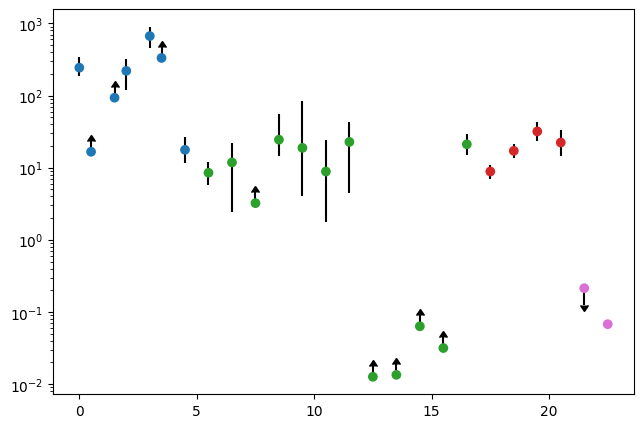

In [8]:
plt.figure(1, figsize=(7.5,5.0))
plt.clf()

rv.errorbar(locs, ratio, fmt=',', color='black')
plt.scatter(locs, ratio.mains, color=colors, zorder=3)
plt.yscale('log')

ax = plt.gca()
plt.show()

Lastly, we complete the plot with more options.

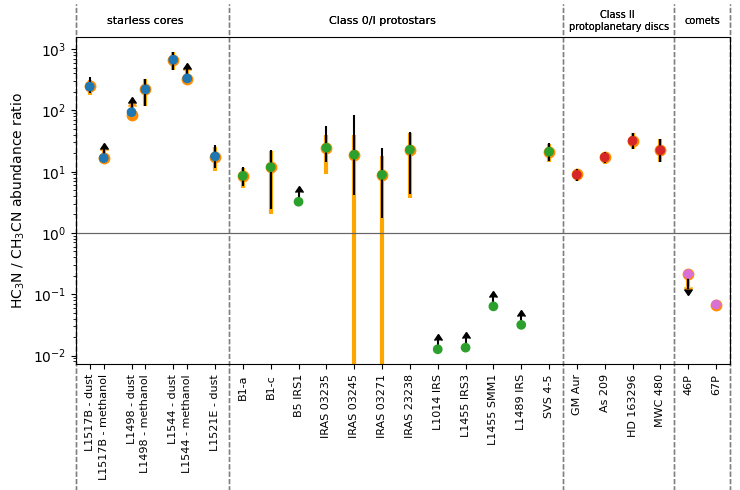

In [11]:
plt.sca(ax)

plt.xlim([-0.5, locs[-1] + 0.5])
plt.axhline(y=1, linestyle='-', linewidth=0.8, color=(0.4,0.4,0.4))
mask = ~ np.isnan(ratio.mains)
plt.xticks(ticks=locs[mask], labels=names[mask], rotation=90,
           fontsize=0.8*fontsize)
plt.ylabel('HC$_3$N / CH$_3$CN abundance ratio')

y_top_labels = 1.05
xrange = np.diff(plt.xlim())
edges = np.array([0, 7, 23, 27, 29])

text_locs = []
for i in range(len(edges)-1):
    i1 = edges[i]
    i2 = edges[i+1]
    text_locs += [0.5 + np.median(locs[i1:i2])]
texts = ['starless cores', 'Class 0/I protostars',
         'Class II \nprotoplanetary discs', 'comets']
fontsizes = fontsize*np.array([0.8, 0.8, 0.7, 0.7])
for i, text, fs in zip(text_locs, texts, fontsizes):
    plt.text(i/xrange, y_top_labels, text, ha='center', va='center',
             fontsize=fs, transform=ax.transAxes)
    
line_locs = [locs[0] - 0.5]
line_locs += list(locs[edges[1:-1]] - 0.5)
line_locs += [locs[-1] + 0.5]
for x in line_locs:
    plt.axvline(x, ymin=-0.5, ymax=1.1, linestyle='--', linewidth=1.,
                color='gray', clip_on=False, zorder=0.5)
    
plt.tight_layout()
plt.show()

That's it!

Below you can set the variable `plot_approx_uncs` to True in order to see the values that we would obtain using the usual analytical formulae for uncertainty propagation, displayed in orange. The approach of RichValues is more precise.

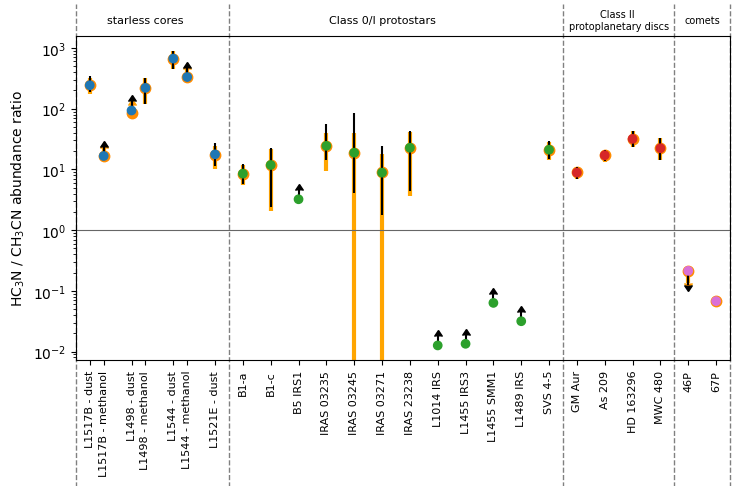

In [10]:
plot_approx_uncs = True

if plot_approx_uncs:
    plt.sca(ax)
    coldens1 = rv.rich_array(data['HC3N'])
    coldens2 = rv.rich_array(data['CH3CN'])
    ratio_approx = []
    for (coldens1i, coldens2i) in zip(coldens1, coldens2):
        if coldens1i.is_centered and coldens2i.is_centered:
            ratio_i = coldens1i.main / coldens2i.main
            rel_unc = (np.array(coldens1i.rel_unc)**2
                       +np.array(coldens2i.rel_unc)**2)**0.5
            ratio_unc = ratio_i * rel_unc
            ratio_approx += [rv.RichValue(ratio_i, ratio_unc)]
        elif coldens1i.is_centered and coldens2i.is_uplim:
            if max(coldens1i.rel_unc) < 0.20:
                lim = coldens1i.main - 3.*coldens1i.unc[0]
                ratio_lim = lim / coldens2i.main
            else:
                ratio_lim = np.nan
            ratio_approx += [rv.RichValue(ratio_lim, is_lolim=True)]
        elif coldens1i.is_uplim and coldens2i.is_centered:
            if max(coldens2i.rel_unc) < 0.20:
                lim = coldens2i.main - 3.*coldens2i.unc[0]
                ratio_lim = coldens1i.main / lim
            else:
                ratio_lim = np.nan
            ratio_approx += [rv.RichValue(ratio_lim, is_uplim=True)]
        else:
            ratio_approx += [rv.RichValue(np.nan)]
    ratio_approx = rv.rich_array(ratio_approx)
    rv.errorbar(locs, ratio_approx, fmt='.', color='darkorange', ecolor='orange',
                ms=15., lw=3., zorder=1.)
    plt.show()

Notice how when the original relative uncertainties were high, the ratio obtained by using the analytical propagation formulae differs quite a lot with the one obtained by RichValues using Monte Carlo simulations, which are more precise. Besides, upper/lower limits cannot be easily propagated analytically when the relative uncertainties are high.

Here we can see that RichValues is not only useful for handling uncertainties because of its ease of use but because it provides accurate uncertainty propagation.